---
단일 변수 범주형 데이터 탐색(Univariate Categorical Data Analysis)
- 하나의 범주형 변수가 전체 데이터에서 어떻게 분포되어 있는지를 파악하는 과정
- 주요 요약 지표

| **지표** | **의미** |
| :--- | :--- |
| 빈도 (Frequency) | 각 범주에 속하는 데이터의 개수 |
| 상대 빈도 (Relative Frequency) | 전체 대비 각 범주의 비율(%) |
| 최빈값 (Mode) | 가장 많이 나타난 범주 |
- 주요 시각화 방법

| **시각화** | **설명** |
| :--- | :--- |
| 막대 그래프 (Bar Chart) | 범주 간 개수 비교에 가장 적합 |
| 파이 차트 (Pie Chart) | 전체에서 각 범주의 비율 표현<br>※ 범주가 많으면 가독성 저하 |

---

---
문자로 표현된 범주형 데이터

In [1]:
import pandas as pd

favorite = pd.Series(["WINTER", "SUMMER", "SPRING", "SUMMER", "SUMMER",
                        "FALL", "FALL", "SUMMER", "SPRING", "SPRING"])
print(favorite)

0    WINTER
1    SUMMER
2    SPRING
3    SUMMER
4    SUMMER
5      FALL
6      FALL
7    SUMMER
8    SPRING
9    SPRING
dtype: str


In [2]:
print(favorite.count())

10


In [3]:
print(favorite.unique())

<StringArray>
['WINTER', 'SUMMER', 'SPRING', 'FALL']
Length: 4, dtype: str


In [4]:
print(favorite.nunique())

4


In [5]:
print(favorite.value_counts()) # 도수 분포

SUMMER    4
SPRING    3
FALL      2
WINTER    1
Name: count, dtype: int64


In [6]:
print(favorite.size)

10


In [7]:
print(favorite.value_counts() / favorite.size) # 비율

SUMMER    0.4
SPRING    0.3
FALL      0.2
WINTER    0.1
Name: count, dtype: float64


In [8]:
fd = favorite.value_counts()
print(type(fd))

<class 'pandas.Series'>


In [9]:
print(fd)

SUMMER    4
SPRING    3
FALL      2
WINTER    1
Name: count, dtype: int64


In [10]:
print(fd["SUMMER"])
print(fd.iloc[0])

4
4


---
> ## 도수 분포표 (Frequency Distribution Table)
> 도수분포표(度數分布表)란 데이터를 일정한 구간으로 나누고, 각 구간에 속한 데이터의 개수를 정리한 표입니다.
## 시각화 그래프 요약
도수분포표를 시각화한 그래프는 막대 그래프, 원 그래프, 히스토그램 등이 있습니다.
| **그래프 종류** | **주요 용도** | **특징** |
| :--- | :--- | :--- |
| **막대 그래프 (Bar Chart)** | 범주형 데이터 비교 | 계절, 성별처럼 서로 떨어진 카테고리 비교에 적합 |
| **히스토그램 (Histogram)** | 연속형 데이터 분포 | 점수, 키, 몸무게처럼 연결된 수치 데이터를 구간 별로 표현 |
| **원 그래프 (Pie Chart)** | 전체 대비 비율 확인 | 각 항목이 전체에서 차지하는 점유율(상대도수) 파악에 용이
---
막대 그래프 작성

In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


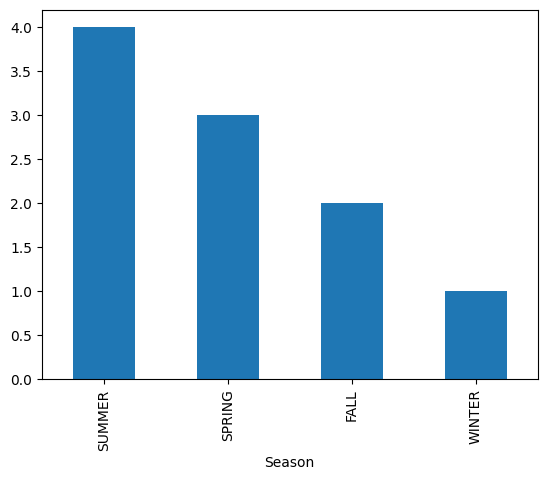

In [12]:
import matplotlib.pyplot as plt

fd.plot.bar(xlabel="Season")

plt.show()

---
| **그래프 종류** | **`rot`가 영향을 주는 축** | **주로 사용하는 이유** |
| :--- | :--- | :--- |
| **`bar` (세로)** | **x축** (범주 이름) | 이름이 길어서 서로 겹칠 때 회전시킴 |
| **`barh` (가로)** | **y축** (범주 이름) | 가로 출력 시에도 글자 방향을 세우고 싶을 때 사용 |

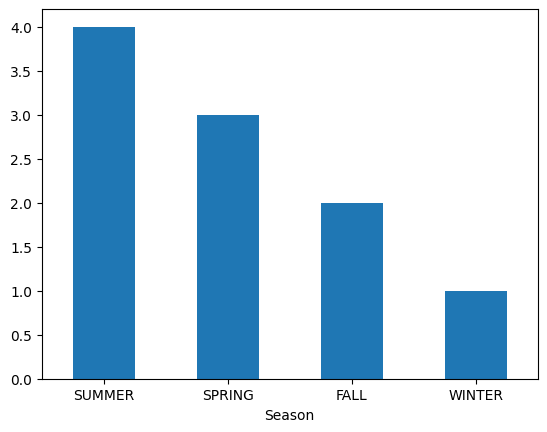

In [13]:
import matplotlib.pyplot as plt

fd.plot.bar(xlabel="Season",
            rot=0)
plt.show()

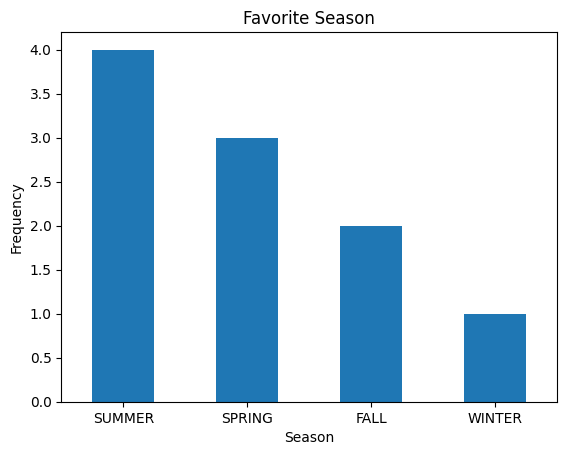

In [14]:
import matplotlib.pyplot as plt

fd.plot.bar(xlabel="Season",
            ylabel="Frequency",
            rot=0,
            title="Favorite Season")
plt.show()

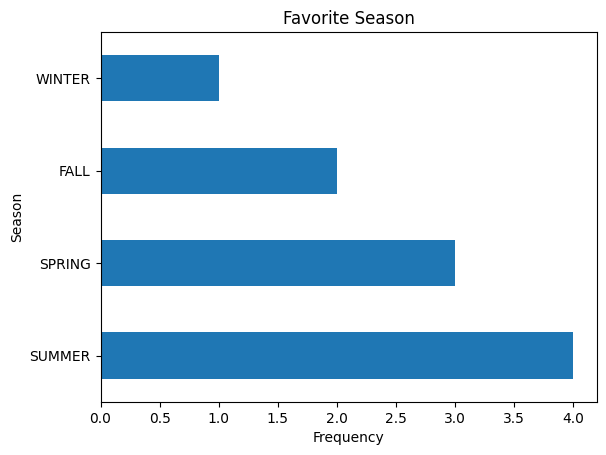

In [15]:
fd.plot.barh(xlabel="Frequency",
             ylabel="Season",
             rot=0,
             title="Favorite Season")
plt.show()

---
원그래프 작성

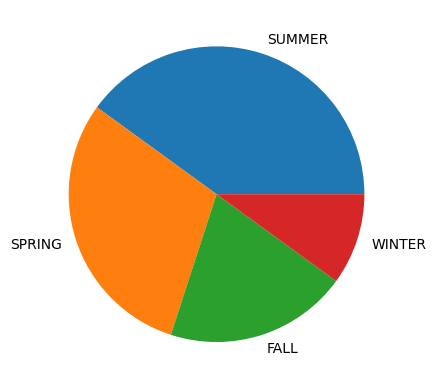

In [16]:
fd.plot.pie()

plt.show()

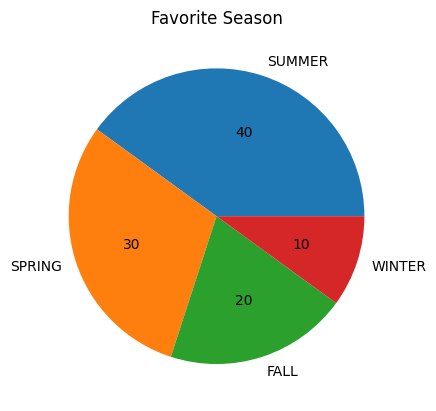

In [17]:
fd.plot.pie(autopct="%1.0f",
            title="Favorite Season")
plt.show()

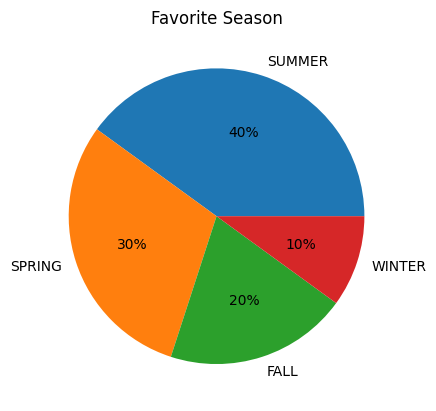

In [18]:
fd.plot.pie(autopct="%1.0f%%",
            title="Favorite Season")
plt.show()

---
숫자로 표현된 범주형 데이터

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

colors = pd.Series([20, 30, 20, 10, 10, 20, 20, 10, 30, 20, 10, 30, 20, 10, 20])

fd = colors.value_counts()
print(fd)

20    7
10    5
30    3
Name: count, dtype: int64


In [20]:
print(colors.value_counts()/colors.size)

20    0.466667
10    0.333333
30    0.200000
Name: count, dtype: float64


In [21]:
print(fd.index)

Index([20, 10, 30], dtype='int64')


In [22]:
fd.index = ["red", "green", "blue"]
print(fd)

red      7
green    5
blue     3
Name: count, dtype: int64


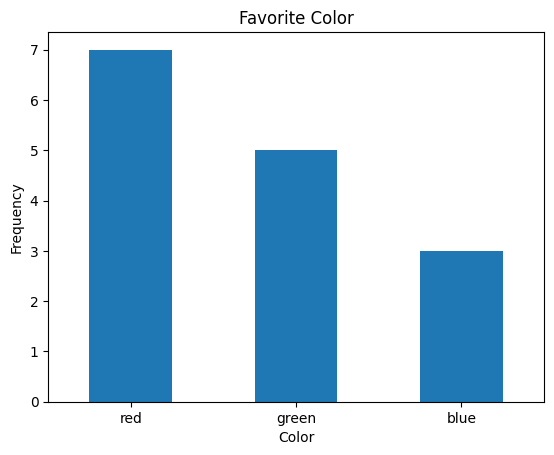

In [23]:
fd.plot.bar(xlabel="Color",
            ylabel="Frequency",
            rot=0,
            title="Favorite Color")
plt.show()

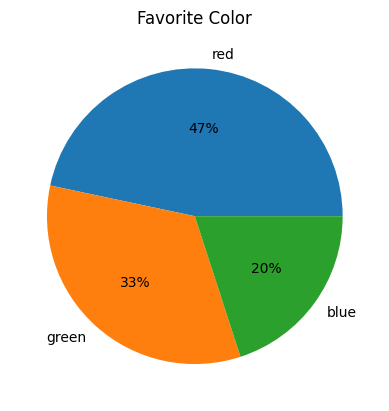

In [24]:
fd.plot.pie(autopct="%1.0f%%",
            title="Favorite Color")
plt.show()

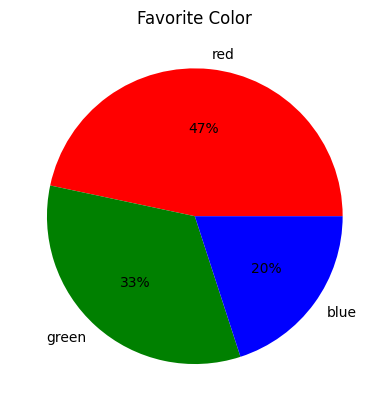

In [25]:
fd.plot.pie(autopct="%1.0f%%",
            title="Favorite Color",
            colors=["red", "green", "blue"])
plt.show()

---
단일 변수 연속성 데이터 탐색
- 단일 변수 연속성 데이터 탐색은 한 개의 수치형 변수의 중심, 퍼짐, 분포 형태, 이상치를 파악하는 것이다.
1. 중심 위치
    - 데이터가 어디에 몰려있는가
    - 평균, 중앙값, 최빈값
2. 퍼짐 정도(산포도)
    - 데이터가 얼마나 흩어져 있는가
    - 분산(variance), 표준편차(std), 범위(range), 사분위수(IQR)
3. 분포 형태
    - 데이터의 모양이 대칭/비대칭, 오른쪽 꼬리/왼쪽 꼬리, 정규분포와의 유사성
    - 시각화로 판단
4. 이상치
    - 다른 값들과 현저히 다른 값
    - 박스플록, IQR 기준

In [26]:
ds = [60, 62, 64, 65, 68, 69]
weight = pd.Series(ds)

In [27]:
ds.append(120)
weight_heavy = pd.Series(ds)

In [28]:
print(weight)

0    60
1    62
2    64
3    65
4    68
5    69
dtype: int64


In [29]:
print(weight_heavy)

0     60
1     62
2     64
3     65
4     68
5     69
6    120
dtype: int64


In [30]:
print(weight.mean())
print(weight_heavy.mean())

64.66666666666667
72.57142857142857


---
중앙값은 특이값에 영향을 덜 받습니다.

In [31]:
print(weight.median())
print(weight_heavy.median())

64.5
65.0


---
절사 평균을 사용하기 위한 패키지 설치

In [32]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


---
- 절사평균(Trimmed Mean): 데이터의 양쪽 극단값(너무 크거나 작은 값)을 일정 비율 제거한 뒤 계산한 평균입니다.
- 일반 평균을 극단값(이상치)에 매우 민감합니다. 극단값의 영향을 줄이기 위해 일정 비율의 데이터를 제거한 평균입니다.
- 절사 비율은 데이터의 이상치 정도와 표본 크기를 고려해 보통 5%~20%에서 선택합니다.

In [33]:
from scipy import stats
print(stats.trim_mean(weight, 0.2))
print(stats.trim_mean(weight_heavy, 0.2))

64.75
65.6


---
- 사분위수(四分位數, Quatiles)란 정렬된 데이터를 4등분하는 기준값(Q1, Q2, Q3)입니다.
- 데이터의 분포 파악과 이상치 판단 기준을 제공합니다.
- quantile()는 데이터의 분위수(quantile)를 계산하는 함수입니다.

In [ ]:
import pandas as pd
import numpy as np

mydata = [60, 62, 64, 65, 68, 69, 120]
mydata = pd.Series(mydata)

In [35]:
q1 = mydata.quantile(0.25)
print(q1)

63.0


In [36]:
q2 = mydata.quantile(0.5)
print(q2)

65.0


In [37]:
q3 = mydata.quantile(0.75)
print(q3)

68.5


In [38]:
q4 = mydata.quantile([0.25, 0.5, 0.75])
print(q4)

0.25    63.0
0.50    65.0
0.75    68.5
dtype: float64


In [39]:
mydata.describe()

count      7.000000
mean      72.571429
std       21.149130
min       60.000000
25%       63.000000
50%       65.000000
75%       68.500000
max      120.000000
dtype: float64

---
- 산포란 주어진 데이터에 있는 값들이 퍼져있는 정도를 의미합니다.
- 산포는 주로 분산과 표준편차를 이용해 파악할 수 있습니다.
- 분산과 표준 편차가 작다라는 의미는 관측값들이 평균값 부근에 모여있다는 의미입니다.
- 분산과 표준 평차가 크다라는 의미는 관측값들이 평균값으로 부터 멀리 흩어져서 분포한다는 의미입니다.

In [40]:
mydata = pd.Series([60, 62, 64, 65, 68, 69, 72])

print(mydata.var())
print(mydata.std())

17.57142857142857
4.191828786034631


---
히스토그램은 외관상 막대그래프와 비슷한 그래프로 연속형 데이터의 분포를 시각화 하는데 사용합니다.

In [41]:
df = pd.read_csv("data/cars.csv")
dist = df["dist"]
print(type(dist))
print(dist)

<class 'pandas.Series'>
0       2
1      10
2       4
3      22
4      16
5      10
6      18
7      26
8      34
9      17
10     28
11     14
12     20
13     24
14     28
15     26
16     34
17     34
18     46
19     26
20     36
21     60
22     80
23     20
24     26
25     54
26     32
27     40
28     32
29     40
30     50
31     42
32     56
33     76
34     84
35     36
36     46
37     68
38     32
39     48
40     52
41     56
42     64
43     66
44     54
45     70
46     92
47     93
48    120
49     85
Name: dist, dtype: int64


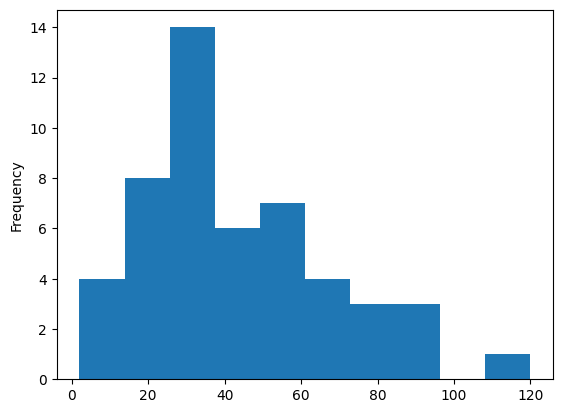

In [42]:
dist.plot.hist()
plt.show()

---
구간별 빈도수

In [43]:
result = dist.value_counts(bins=10, sort=False)
print(result)

(1.881, 13.8]      4
(13.8, 25.6]       8
(25.6, 37.4]      14
(37.4, 49.2]       6
(49.2, 61.0]       7
(61.0, 72.8]       4
(72.8, 84.6]       3
(84.6, 96.4]       3
(96.4, 108.2]      0
(108.2, 120.0]     1
Name: count, dtype: int64


In [44]:
print(dist.min())
print(dist.max())

2
120


데이터의 최솟값이 2임에도 불구하고 구간의 시작이 1.881인 이유는 데이터의 최솟값(2)을 첫 번째 구간에 안전하게 포함시키기 위한 Pandas의 내부 알고리즘 때문입니다.
1. 구간의 형태: (a, b] (왼쪽은 열려 있고, 오른쪽은 닫혀있음)
    - Pandas의 value_counts(bins=n)나 pd.cut 함수는 기본적으로 구간을 "왼쪽 경계 미포함, 오른쪽 경계 포함"하는 방식은 (a, b] 형태로 만듭니다.
    - 만약 첫 번째 구간이 (2, 13.8]로 시작한다면, "2 초과 13.8 이하" 라는 뜻이 됩니다.
    - 데이터 중 가장 작은 값인 2는 정작 어느 구간에도 속하지 못하고 누락되는 문제가 발생합니다.
2. 0.1% 확장 법칙

    (1) 범위 계산: 120(최댓값) - 2(최솟값) = 118<br>
    (2) 확장 값 계산: 118 * 0.001 = 0.118<br>
    (3) 시작점 결정: 2(최솟값) - 0.118 = 1.882<br>

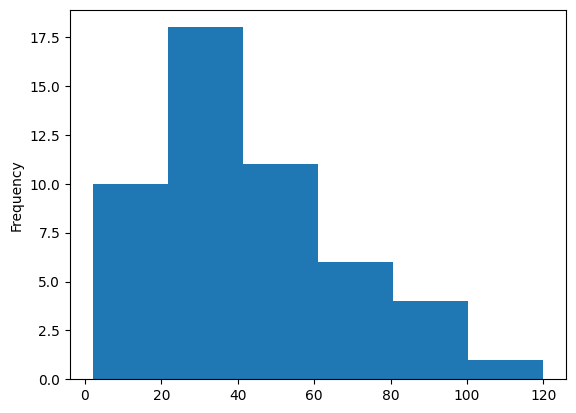

In [46]:
dist.plot.hist(bins=6)
plt.show()

In [45]:
result = dist.value_counts(bins=6, sort=False)
print(result)

(1.881, 21.667]      10
(21.667, 41.333]     18
(41.333, 61.0]       11
(61.0, 80.667]        6
(80.667, 100.333]     4
(100.333, 120.0]      1
Name: count, dtype: int64


---
상자 그림(box plot)은 상자 수염 그림(box and whisker plot)으로도 불리며 사분위수를 시각화하여 그래프 형태로 나타낸 것 입니다.
- 상자 그림은 하나의 그래프로 데이터의 분포 형태를 포함한 다양한 정보를 전달하기 때문에 단일 변수 연속형(수치형) 자료를 파악하는데 자주 사용됩니다.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/cars.csv")
print(type(df))

<class 'pandas.DataFrame'>


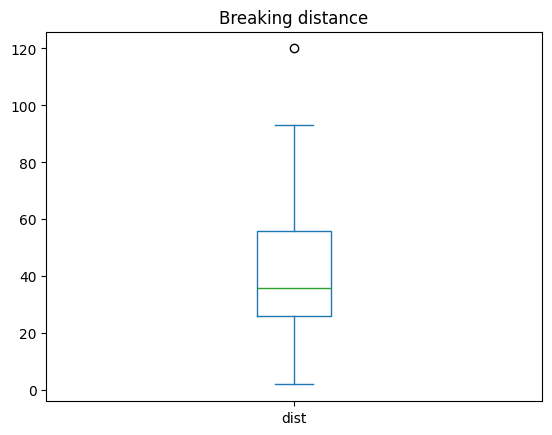

In [48]:
dist = df["dist"]

dist.plot.box(title="Breaking distance")
plt.show()

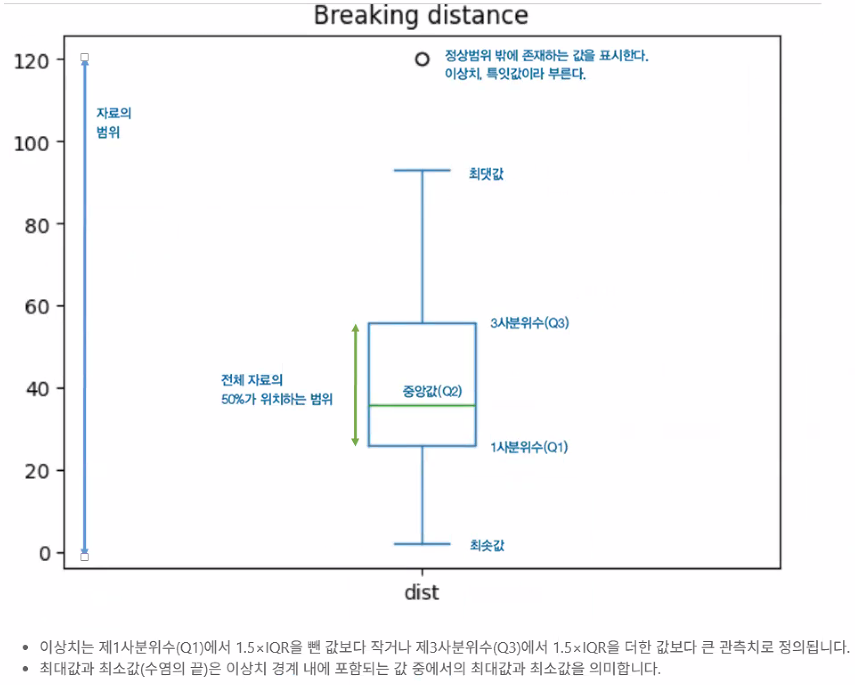
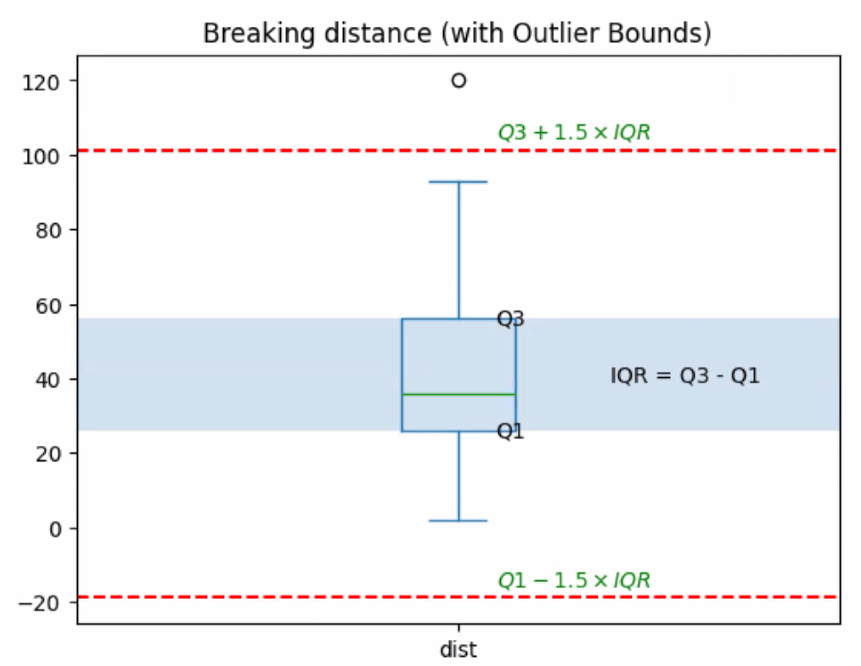

---
그룹이 있는 데이터의 상자 그림

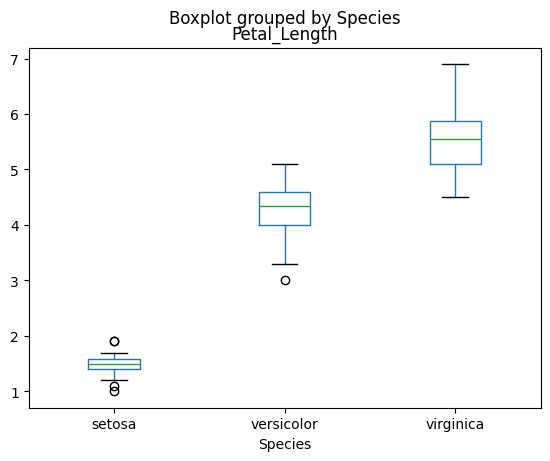

In [49]:
df = pd.read_csv("data/iris.csv")

df.boxplot(column="Petal_Length",
           by="Species",
           grid=False)

plt.show()

- setosa 품종의 꽃잎 길이가 가장 짧고 virginica 품종의 꽃잎 길이가 전반적으로 가장 길다는 것을 알 수 있습니다.
- setosa 품종의 값들이 좁은 지역에 모여 있습니다.
- setosa 품종의 꽃들은 꽃잎 길이가 비슷하다는 의미입니다. 반면 versicolor와 virginica 품종의 꽃은 데이터의 분포가 넓게 퍼져 있습니다.
---
판다스 그래프
- 다양한 매개변수를 지정하여 막대 그래프를 작성합니다.

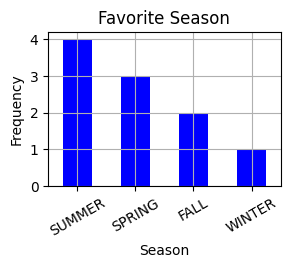

In [50]:
favorite = pd.Series(['WINTER', 'SUMMER', 'SPRING', 'SUMMER', 'SUMMER',
                      'FALL', 'FALL', 'SUMMER', 'SPRING', 'SPRING'])
fd = favorite.value_counts()

fd.plot.bar(xlabel='Season',
            ylabel='Frequency',
            rot=30,
            title='Favorite Season',
            color='b',
            grid=True,
            figsize=(3, 2)) # inch

plt.show()

---
판다스 그래프에서 한글 표시 하기 위한 두 가지 설정
1. 한글 폰트(예: Malgun Gothic, NanumGothic) 설정<br><br>
방법) plt.rcParams['font.family'] = 'Malgun Gothic'

2. 마이너스(-) 부호 깨짐 방지 설정<br><br>
방법) plt.rcParams['axes.unicode_minus'] = False
    - 한글 폰트는 유니코드 마이너스(-)를 지원하지 않는 경우가 많아 음수 값이 깨져 보일 수 있습니다.

In [51]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ser = pd.Series([3, 1, 1, 2])

result = ser.value_counts().sort_index()
print(result)

1    2
2    1
3    1
Name: count, dtype: int64


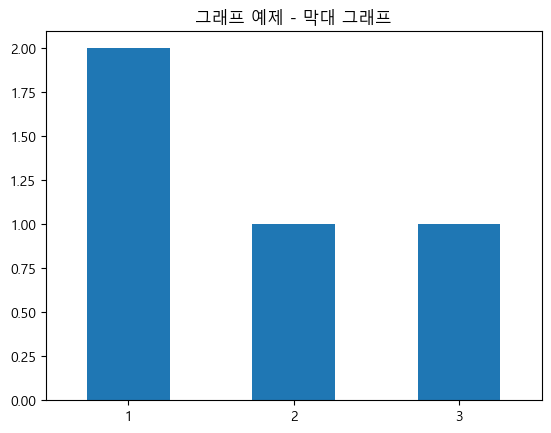

In [52]:
result.plot.bar(rot=0)

plt.title('그래프 예제 - 막대 그래프')
plt.show()

c:\workspace\ai_dev\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


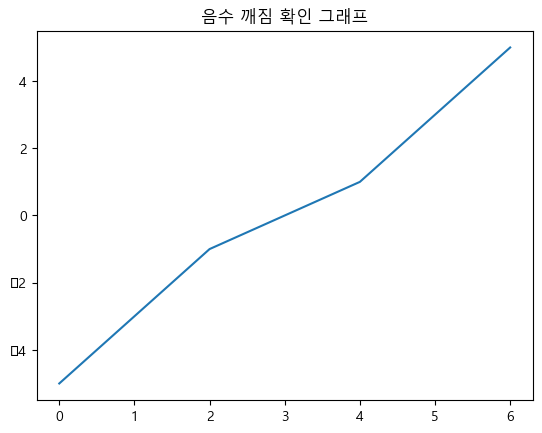

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = True

ser = pd.Series([-5, -3, -1, 0, 1, 3, 5])
ser.plot(title="음수 깨짐 확인 그래프")

plt.show()

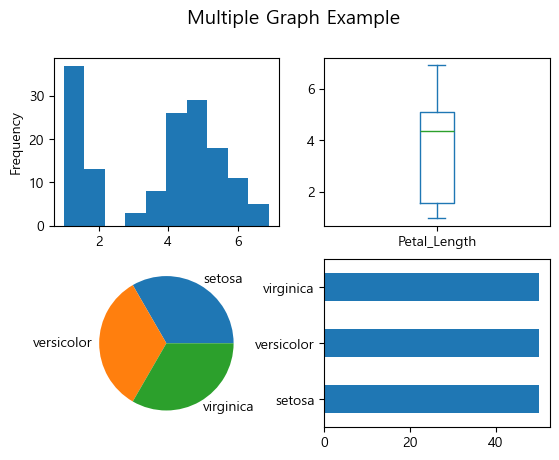

In [55]:
df = pd.read_csv('data/iris.csv')

fig, axes = plt.subplots(nrows=2, ncols=2)

df['Petal_Length'].plot.hist(ax=axes[0, 0])

df['Petal_Length'].plot.box(ax=axes[0, 1])

fd = df['Species'].value_counts()
fd.plot.pie(ax=axes[1, 0], ylabel='')
fd.plot.barh(ax=axes[1, 1], ylabel='')

fig.suptitle('Multiple Graph Example', fontsize=14)

plt.show()